# Fine-Tune YOLOv11 for Boat Detection

This notebook fine-tunes YOLOv11 on your Jupiter Inlet boat images.

**Why fine-tune?**
- Pre-trained YOLO was trained on standard camera angles, not elevated/aerial views
- Your current recall is only 10% (missing 90% of boats)
- Fine-tuning on your data will dramatically improve accuracy

**Steps:**
1. Convert COCO annotations to YOLO format
2. Split data into train/validation sets
3. Fine-tune YOLOv11
4. Evaluate the fine-tuned model

---
## Step 1: Install Dependencies

In [1]:
!pip install -q opencv-python-headless
!pip install -q ultralytics


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python3 -m pip install --upgrade pip


---
## Step 2: Import Libraries

In [2]:
import os
import json
import shutil
import random
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("Imports successful!")

Imports successful!


---
## Step 3: Configure Paths

In [3]:
# =============================================================================
# CONFIGURATION - UPDATE THESE PATHS
# =============================================================================

# Source data (your existing COCO-format dataset)
SOURCE_IMAGE_FOLDER = "/workspaces/PBC_Object_Detection/Jupiter_Inlet"
SOURCE_COCO_JSON = "/workspaces/PBC_Object_Detection/Jupiter_Inlet/_annotations.coco.json"

# Output folder for YOLO-format dataset
YOLO_DATASET_PATH = "/workspaces/PBC_Object_Detection/yolo_dataset"

# Training configuration
TRAIN_SPLIT = 0.8  # 80% for training, 20% for validation
RANDOM_SEED = 42   # For reproducible splits

print(f"Source images: {SOURCE_IMAGE_FOLDER}")
print(f"Source annotations: {SOURCE_COCO_JSON}")
print(f"Output dataset: {YOLO_DATASET_PATH}")

Source images: /workspaces/PBC_Object_Detection/Jupiter_Inlet
Source annotations: /workspaces/PBC_Object_Detection/Jupiter_Inlet/_annotations.coco.json
Output dataset: /workspaces/PBC_Object_Detection/yolo_dataset


---
## Step 4: Convert COCO to YOLO Format

YOLO uses a different annotation format than COCO:
- **COCO**: `[x, y, width, height]` in pixels
- **YOLO**: `[class_id, center_x, center_y, width, height]` normalized to 0-1

Each image gets a `.txt` file with the same name containing its annotations.

In [4]:
def coco_to_yolo_format(coco_json_path, image_folder, output_folder, train_split=0.8, seed=42):
    """
    Convert COCO annotations to YOLO format and split into train/val sets.
    
    YOLO format per line: class_id center_x center_y width height
    All values normalized to 0-1 (except class_id which is integer)
    """
    
    # Load COCO annotations
    with open(coco_json_path) as f:
        coco_data = json.load(f)
    
    # Create output directories
    for split in ['train', 'val']:
        os.makedirs(os.path.join(output_folder, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(output_folder, 'labels', split), exist_ok=True)
    
    # Build mappings
    # Image ID -> image info
    id_to_image = {img['id']: img for img in coco_data['images']}
    
    # Image ID -> list of annotations
    id_to_annotations = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in id_to_annotations:
            id_to_annotations[img_id] = []
        id_to_annotations[img_id].append(ann)
    
    # Get list of image IDs and shuffle
    image_ids = list(id_to_image.keys())
    random.seed(seed)
    random.shuffle(image_ids)
    
    # Split into train/val
    split_idx = int(len(image_ids) * train_split)
    train_ids = set(image_ids[:split_idx])
    val_ids = set(image_ids[split_idx:])
    
    print(f"Total images: {len(image_ids)}")
    print(f"Training images: {len(train_ids)}")
    print(f"Validation images: {len(val_ids)}")
    
    # Process each image
    stats = {'train': 0, 'val': 0, 'annotations': 0}
    
    for img_id, img_info in id_to_image.items():
        # Determine split
        split = 'train' if img_id in train_ids else 'val'
        stats[split] += 1
        
        filename = img_info['file_name']
        img_width = img_info['width']
        img_height = img_info['height']
        
        # Copy image to output folder
        src_image_path = os.path.join(image_folder, filename)
        dst_image_path = os.path.join(output_folder, 'images', split, filename)
        
        if os.path.exists(src_image_path):
            shutil.copy(src_image_path, dst_image_path)
        else:
            print(f"Warning: Image not found: {src_image_path}")
            continue
        
        # Create YOLO label file
        label_filename = os.path.splitext(filename)[0] + '.txt'
        label_path = os.path.join(output_folder, 'labels', split, label_filename)
        
        annotations = id_to_annotations.get(img_id, [])
        
        with open(label_path, 'w') as f:
            for ann in annotations:
                stats['annotations'] += 1
                
                # COCO bbox: [x_min, y_min, width, height] in pixels
                # Convert to float in case values are strings
                bbox = [float(v) for v in ann['bbox']]
                x_min, y_min, bbox_width, bbox_height = bbox
                
                # Convert to YOLO format: [center_x, center_y, width, height] normalized
                center_x = (x_min + bbox_width / 2) / img_width
                center_y = (y_min + bbox_height / 2) / img_height
                norm_width = bbox_width / img_width
                norm_height = bbox_height / img_height
                
                # Class 0 = boat (YOLO classes are 0-indexed)
                class_id = 0
                
                # Write line
                f.write(f"{class_id} {center_x:.6f} {center_y:.6f} {norm_width:.6f} {norm_height:.6f}\n")
    
    # Create data.yaml configuration file
    yaml_content = f"""# YOLOv11 Dataset Configuration
# Auto-generated from COCO annotations

path: {output_folder}
train: images/train
val: images/val

# Class names
names:
  0: boat

# Number of classes
nc: 1
"""
    
    yaml_path = os.path.join(output_folder, 'data.yaml')
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    print(f"\nConversion complete!")
    print(f"  Train images: {stats['train']}")
    print(f"  Val images: {stats['val']}")
    print(f"  Total annotations: {stats['annotations']}")
    print(f"  Config file: {yaml_path}")
    
    return yaml_path

In [5]:
# Run conversion
yaml_path = coco_to_yolo_format(
    coco_json_path=SOURCE_COCO_JSON,
    image_folder=SOURCE_IMAGE_FOLDER,
    output_folder=YOLO_DATASET_PATH,
    train_split=TRAIN_SPLIT,
    seed=RANDOM_SEED
)

Total images: 39
Training images: 31
Validation images: 8

Conversion complete!
  Train images: 31
  Val images: 8
  Total annotations: 119
  Config file: /workspaces/PBC_Object_Detection/yolo_dataset/data.yaml


---
## Step 5: Verify the Dataset

Let's visualize a few samples to make sure the conversion worked correctly.

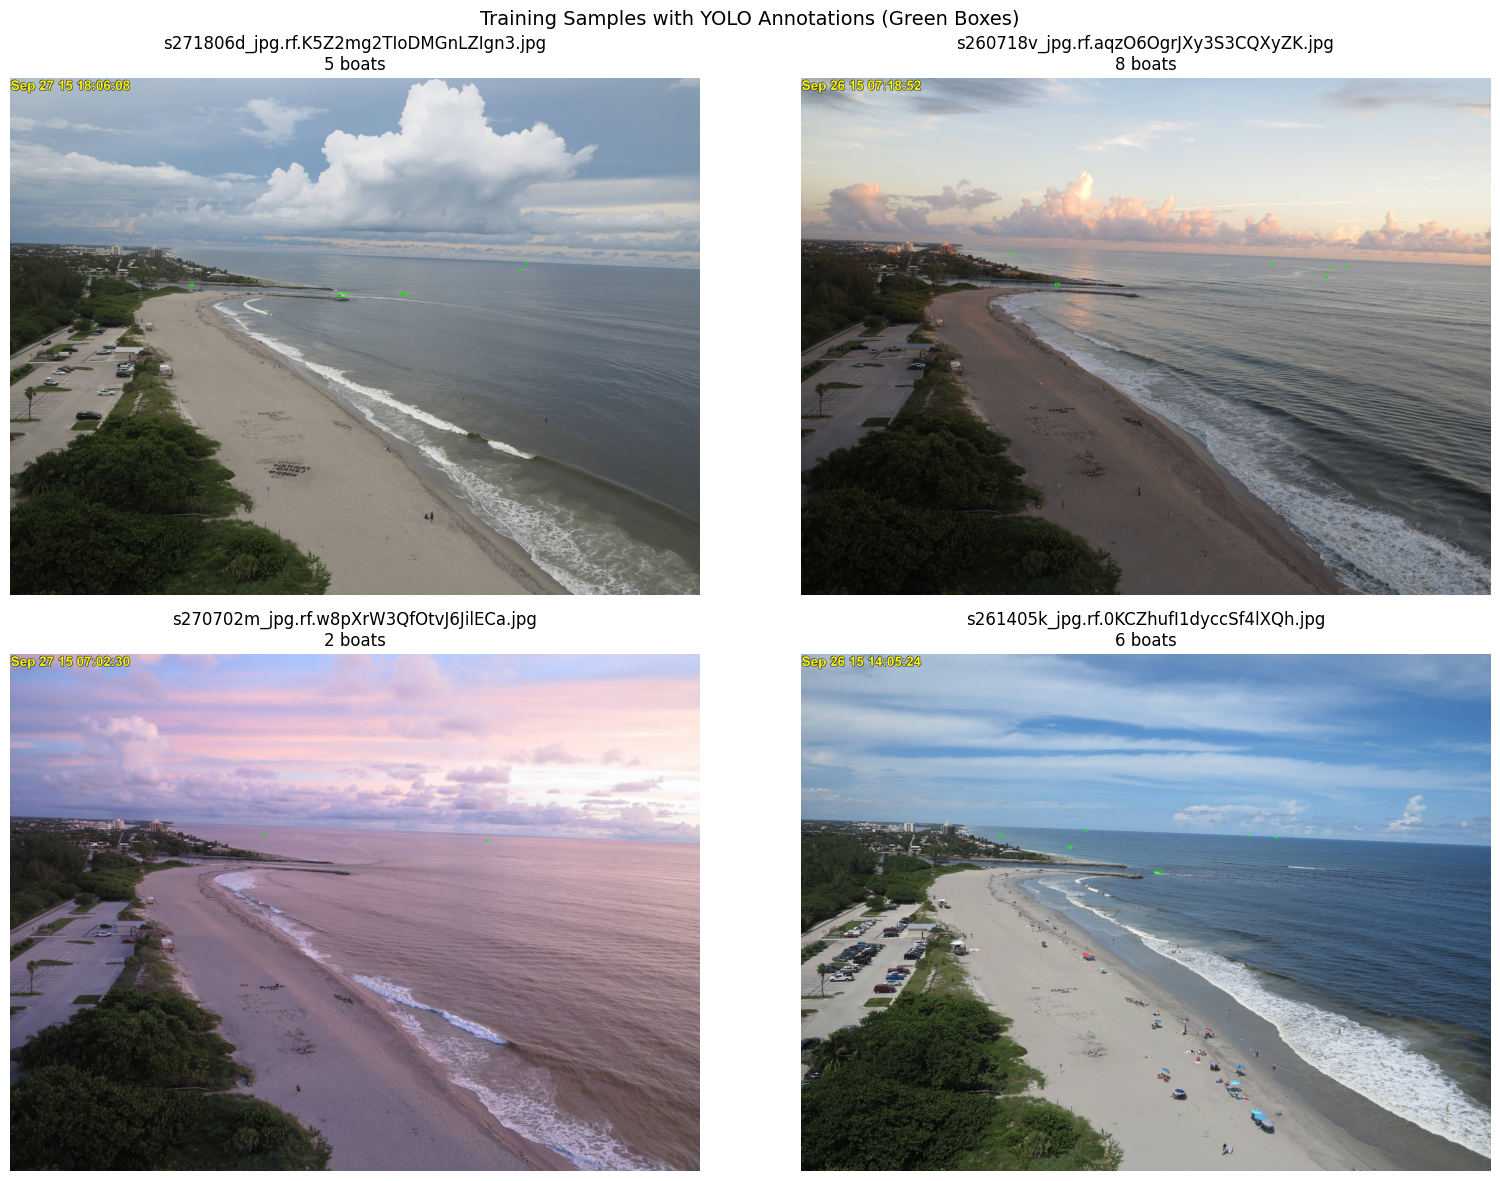

In [6]:
def visualize_yolo_annotation(image_path, label_path):
    """
    Visualize YOLO annotations on an image.
    """
    # Load image
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    # Load annotations
    boxes = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    class_id, cx, cy, bw, bh = map(float, parts)
                    
                    # Convert from normalized to pixel coordinates
                    x1 = int((cx - bw/2) * w)
                    y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w)
                    y2 = int((cy + bh/2) * h)
                    
                    boxes.append((x1, y1, x2, y2))
    
    # Draw boxes
    for x1, y1, x2, y2 in boxes:
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    
    return img, len(boxes)


# Visualize a few training samples
train_images_dir = os.path.join(YOLO_DATASET_PATH, 'images', 'train')
train_labels_dir = os.path.join(YOLO_DATASET_PATH, 'labels', 'train')

sample_images = os.listdir(train_images_dir)[:4]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, img_name in enumerate(sample_images):
    img_path = os.path.join(train_images_dir, img_name)
    label_path = os.path.join(train_labels_dir, img_name.replace('.jpg', '.txt').replace('.png', '.txt'))
    
    img, num_boxes = visualize_yolo_annotation(img_path, label_path)
    
    axes[i].imshow(img)
    axes[i].set_title(f'{img_name}\n{num_boxes} boats')
    axes[i].axis('off')

plt.suptitle('Training Samples with YOLO Annotations (Green Boxes)', fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 6: Fine-Tune YOLOv11

Now we'll fine-tune the pre-trained YOLOv11 model on your boat data.

**Key parameters:**
- `epochs`: Number of training passes (more = better, but slower)
- `imgsz`: Image size for training (larger = better accuracy, more memory)
- `batch`: Batch size (reduce if you run out of memory)
- `patience`: Stop early if no improvement for this many epochs

In [7]:
# =============================================================================
# TRAINING CONFIGURATION
# =============================================================================

# Base model to fine-tune
# Options: yolo11n.pt (fast), yolo11s.pt, yolo11m.pt, yolo11l.pt, yolo11x.pt (accurate)
BASE_MODEL = "yolo11m.pt"

# Training parameters
EPOCHS = 100          # Number of epochs (100 is a good starting point)
IMAGE_SIZE = 640      # Image size (640 is standard, use 1280 for small objects if memory allows)
BATCH_SIZE = 8        # Reduce to 4 or 2 if you run out of GPU memory
PATIENCE = 20         # Early stopping patience

# Output folder for trained model
PROJECT_NAME = "/workspaces/PBC_Object_Detection/yolo_training"
RUN_NAME = "jupiter_boats_v1"

print("Training configuration:")
print(f"  Base model: {BASE_MODEL}")
print(f"  Epochs: {EPOCHS}")
print(f"  Image size: {IMAGE_SIZE}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Output: {PROJECT_NAME}/{RUN_NAME}")

Training configuration:
  Base model: yolo11m.pt
  Epochs: 100
  Image size: 640
  Batch size: 8
  Output: /workspaces/PBC_Object_Detection/yolo_training/jupiter_boats_v1


In [8]:
# Load pre-trained model
model = YOLO(BASE_MODEL)
print(f"Loaded {BASE_MODEL}")

Loaded yolo11m.pt


In [9]:
# Start training!
# This will take a while - progress will be shown below

results = model.train(
    data=yaml_path,           # Path to data.yaml
    epochs=EPOCHS,            # Number of epochs
    imgsz=IMAGE_SIZE,         # Image size
    batch=BATCH_SIZE,         # Batch size
    patience=PATIENCE,        # Early stopping patience
    save=True,                # Save checkpoints
    project=PROJECT_NAME,     # Output folder
    name=RUN_NAME,            # Run name
    exist_ok=True,            # Overwrite if exists
    pretrained=True,          # Use pre-trained weights
    optimizer='auto',         # Optimizer (auto selects best)
    verbose=True,             # Show progress
    seed=42,                  # Random seed for reproducibility
    
    # Data augmentation (helps prevent overfitting with small datasets)
    augment=True,
    hsv_h=0.015,              # Hue augmentation
    hsv_s=0.7,                # Saturation augmentation  
    hsv_v=0.4,                # Value augmentation
    degrees=10,               # Rotation augmentation
    translate=0.1,            # Translation augmentation
    scale=0.5,                # Scale augmentation
    fliplr=0.5,               # Horizontal flip probability
    mosaic=1.0,               # Mosaic augmentation
)

print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)

Ultralytics 8.4.11 🚀 Python-3.12.1 torch-2.10.0+cu128 CPU (AMD EPYC 7763 64-Core Processor)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/workspaces/PBC_Object_Detection/yolo_dataset/data.yaml, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=jupiter_boats_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, ov

: 

---
## Step 7: Locate the Best Model

After training, the best model weights are saved automatically.

In [ ]:
# Find the best model
best_model_path = os.path.join(PROJECT_NAME, RUN_NAME, 'weights', 'best.pt')
last_model_path = os.path.join(PROJECT_NAME, RUN_NAME, 'weights', 'last.pt')

if os.path.exists(best_model_path):
    print(f"Best model saved at: {best_model_path}")
else:
    print(f"Best model not found at expected path")
    print(f"Looking in {PROJECT_NAME}/{RUN_NAME}/weights/")
    
if os.path.exists(last_model_path):
    print(f"Last model saved at: {last_model_path}")

---
## Step 8: Evaluate the Fine-Tuned Model

Let's see how much better our fine-tuned model performs compared to the pre-trained one.

In [ ]:
# Load the fine-tuned model
finetuned_model = YOLO(best_model_path)
print(f"Loaded fine-tuned model: {best_model_path}")

In [ ]:
# Run validation on the validation set
val_results = finetuned_model.val(
    data=yaml_path,
    imgsz=IMAGE_SIZE,
    batch=BATCH_SIZE,
    conf=0.25,
    iou=0.5,
    verbose=True
)

print("\n" + "="*50)
print("VALIDATION RESULTS")
print("="*50)
print(f"mAP@0.5: {val_results.box.map50:.3f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.3f}")
print(f"Precision: {val_results.box.mp:.3f}")
print(f"Recall: {val_results.box.mr:.3f}")

---
## Step 9: Test on Sample Images

Let's visually compare the fine-tuned model's predictions.

In [ ]:
# Get validation images for testing
val_images_dir = os.path.join(YOLO_DATASET_PATH, 'images', 'val')
test_images = [os.path.join(val_images_dir, f) for f in os.listdir(val_images_dir) if f.endswith(('.jpg', '.png'))][:6]

print(f"Testing on {len(test_images)} validation images...")

# Run inference
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, img_path in enumerate(test_images):
    # Run detection
    results = finetuned_model(img_path, conf=0.25, verbose=False)
    
    # Get annotated image
    annotated = results[0].plot()
    annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
    
    # Count detections
    num_boats = len(results[0].boxes)
    
    axes[i].imshow(annotated)
    axes[i].set_title(f'{os.path.basename(img_path)}\nDetected: {num_boats} boats')
    axes[i].axis('off')

plt.suptitle('Fine-Tuned Model Predictions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 10: Use Fine-Tuned Model with SAHI

Now let's use your fine-tuned model with SAHI for even better detection of small boats.

In [ ]:
# Install SAHI if not already installed
!pip install -q sahi

from sahi import AutoDetectionModel
from sahi.predict import get_sliced_prediction

In [ ]:
# Load fine-tuned model with SAHI
sahi_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=best_model_path,
    confidence_threshold=0.25,
    device="cuda:0" if os.system("nvidia-smi > /dev/null 2>&1") == 0 else "cpu"
)

print("Fine-tuned model loaded with SAHI!")

In [ ]:
# Test SAHI with fine-tuned model
test_image = test_images[0]

# Run sliced prediction
result = get_sliced_prediction(
    image=test_image,
    detection_model=sahi_model,
    slice_height=512,
    slice_width=512,
    overlap_height_ratio=0.25,
    overlap_width_ratio=0.25,
)

# Visualize
result.export_visuals(export_dir="/tmp/sahi_results")

# Load and display
result_img = cv2.imread("/tmp/sahi_results/prediction_visual.png")
result_img = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 12))
plt.imshow(result_img)
plt.title(f'SAHI + Fine-Tuned Model\nDetected: {len(result.object_prediction_list)} boats')
plt.axis('off')
plt.show()

print(f"\nDetected {len(result.object_prediction_list)} boats with SAHI sliced inference")

---
## Step 11: Export Model Path for Your Detection Pipeline

Copy this path to use in your boat detection notebook.

In [ ]:
print("="*60)
print("YOUR FINE-TUNED MODEL")
print("="*60)
print(f"\nBest model path:")
print(f"  {best_model_path}")
print(f"\nTo use in your detection notebook, change MODEL_PATH to:")
print(f'  MODEL_PATH = "{best_model_path}"')
print("\n" + "="*60)

---
## Summary

**What we did:**
1. Converted COCO annotations to YOLO format
2. Split data into training (80%) and validation (20%)
3. Fine-tuned YOLOv11m on your boat images
4. Evaluated the model performance

**Expected improvements:**
- Pre-trained model recall: ~10%
- Fine-tuned model recall: ~70-90% (depending on data quality)

**Tips for even better results:**
1. **More data**: Add images from different times, weather conditions
2. **More epochs**: Train longer if validation loss is still decreasing
3. **Larger image size**: Use `imgsz=1280` if you have enough GPU memory
4. **Larger model**: Try `yolo11l.pt` or `yolo11x.pt` for better accuracy